<a href="https://colab.research.google.com/github/Prerna-Karle/Advance-Quantum-Computation/blob/main/P04_Extend_Grovers_algorithm_for_a_3_qubit_oracle_and_analyze_iterations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00


In [2]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00


In [3]:
#Import Required Libraries
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Create Oracle (Mark State |101⟩)
def oracle(qc):
    # Mark state |101>

    # Apply X to qubits where target bit is 0
    qc.x(1)  # because middle bit is 0 in 101

    # Apply multi-controlled Z
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)

    # Undo X
    qc.x(1)

In [5]:
#Diffusion Operator (Amplitude Amplification)
def diffusion(qc):
    qc.h([0,1,2])
    qc.x([0,1,2])

    qc.h(2)
    qc.ccx(0,1,2)
    qc.h(2)

    qc.x([0,1,2])
    qc.h([0,1,2])

In [6]:
#Build Grover Circuit with Variable Iterations
def grover_circuit(iterations):
    qc = QuantumCircuit(3, 3)

    # Step 1: Superposition
    qc.h([0,1,2])

    # Step 2: Apply Grover iterations
    for _ in range(iterations):
        oracle(qc)
        diffusion(qc)

    # Step 3: Measurement
    qc.measure([0,1,2], [0,1,2])

    return qc

In [7]:
#Run Simulation
simulator = Aer.get_backend('qasm_simulator')

def run_grover(iterations):
    qc = grover_circuit(iterations)
    job = simulator.run(qc, shots=1024)
    result = job.result()
    counts = result.get_counts()
    return counts

In [8]:
#Analyze Results for Different Iterations
results = {}

for i in range(1, 5):
    counts = run_grover(i)
    results[i] = counts
    print(f"Iterations = {i}")
    print(counts)
    plot_histogram(counts)
    plt.show()

Iterations = 1
{'110': 28, '011': 34, '111': 42, '100': 28, '010': 31, '000': 35, '001': 34, '101': 792}
Iterations = 2
{'110': 6, '100': 6, '011': 8, '111': 9, '010': 6, '000': 10, '001': 7, '101': 972}
Iterations = 3
{'001': 93, '010': 96, '000': 101, '100': 96, '110': 105, '101': 334, '111': 108, '011': 91}
Iterations = 4
{'101': 7, '001': 159, '110': 143, '010': 163, '000': 127, '100': 160, '111': 134, '011': 131}


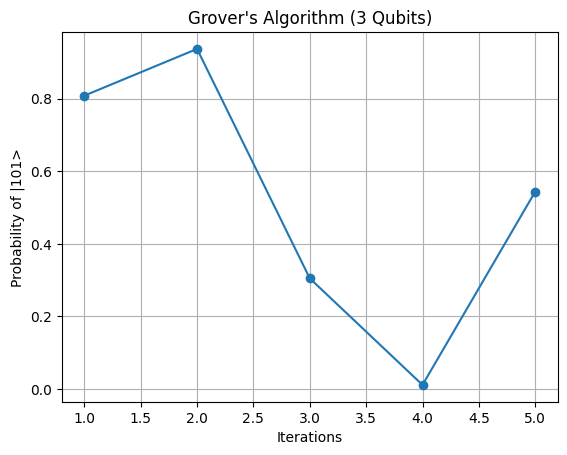

In [9]:
#Plot Probability of Target State
target = '101'
probabilities = []

for i in range(1, 6):
    counts = run_grover(i)
    prob = counts.get(target, 0) / 1024
    probabilities.append(prob)

plt.plot(range(1,6), probabilities, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Probability of |101>")
plt.title("Grover's Algorithm (3 Qubits)")
plt.grid()
plt.show()